# 1: Data Loading & Initial Inspection

In [1]:
# Import core data science libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer

# Configure plotting aesthetics for professional reports
sns.set_theme(style="whitegrid")

# Load the Breast Cancer Wisconsin dataset
cancer_data = load_breast_cancer()

# Construct the primary DataFrame
df = pd.DataFrame(data=cancer_data.data, columns=cancer_data.feature_names)

# Append the target variable 
# Note: In this specific sklearn dataset, 0 denotes 'Malignant' and 1 denotes 'Benign'
df['target'] = cancer_data.target 

# Display foundational dataset metrics
print(f"Dataset Dimensions (Rows, Columns): {df.shape}")
print("\nClass Distribution (Target Variable):")
print(df['target'].map({0: 'Malignant', 1: 'Benign'}).value_counts())

# Inspect the first five records to verify structure
display(df.head())

Dataset Dimensions (Rows, Columns): (569, 31)

Class Distribution (Target Variable):
target
Benign       357
Malignant    212
Name: count, dtype: int64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


# 2: Target Variable Visualization

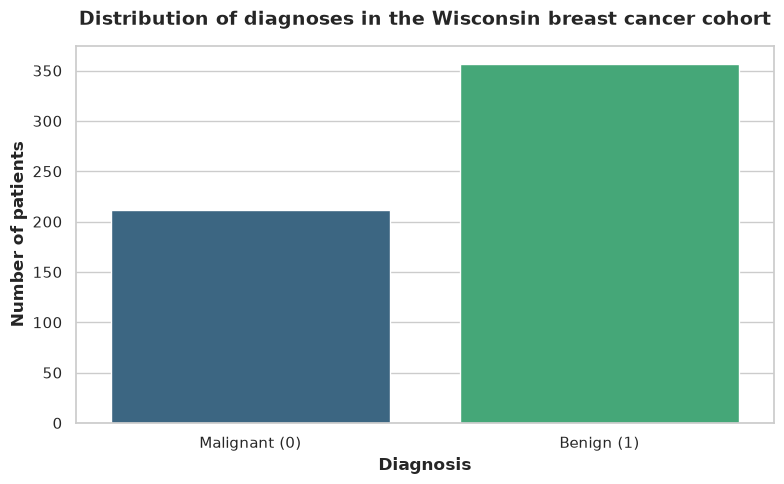

In [11]:
# Visualize the class balance within the dataset
plt.figure(figsize=(8, 5))

# Using 'viridis' palette as it is colorblind-friendly and standard in scientific plotting
ax = sns.countplot(data=df, x='target', hue='target', palette='viridis', legend=False)

# Format axes and labels for clear communication
ax.set_xticks([0, 1])
ax.set_xticklabels(['Malignant (0)', 'Benign (1)'], fontsize=11)
plt.title('Distribution of diagnoses in the Wisconsin breast cancer cohort', fontsize=14, pad=15, fontweight='bold')
plt.ylabel('Number of patients', fontsize=12, fontweight='bold')
plt.xlabel('Diagnosis', fontsize=12, fontweight='bold')

# Ensure layout is strictly bound and display
plt.tight_layout()
plt.show()

# 3: Feature Correlation Analysis

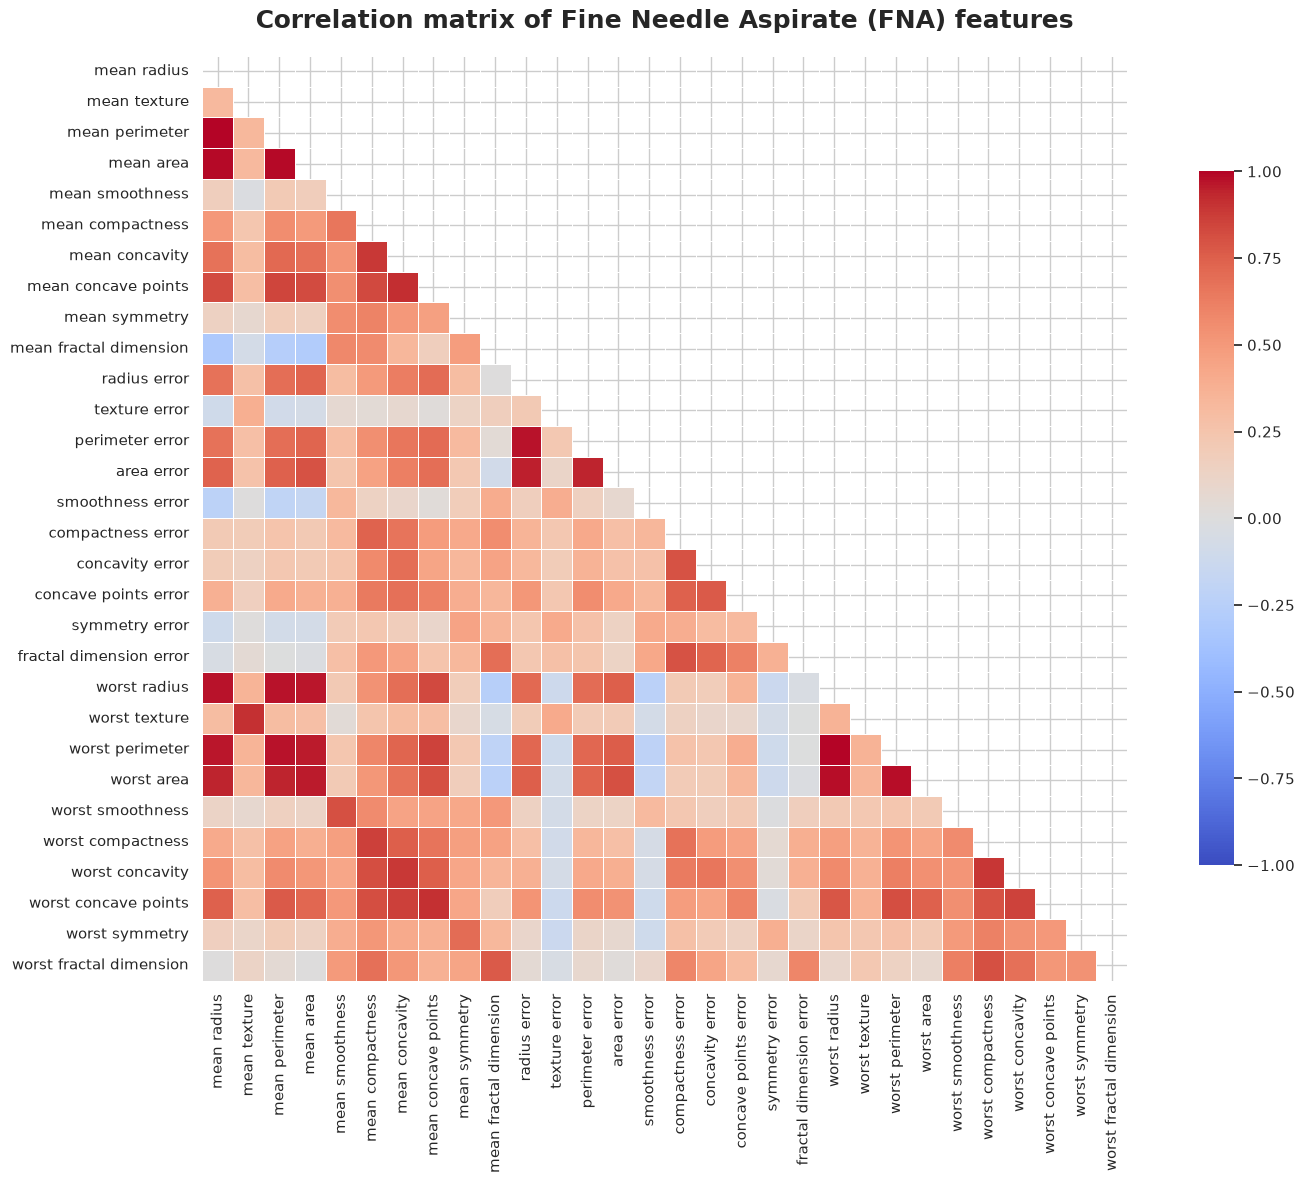

In [12]:
# Calculate the correlation matrix for all numerical features
# Note: We drop the 'target' column here to focus solely on the relationships between the physical cell metrics
correlation_matrix = df.drop(columns=['target']).corr()

# Set up the matplotlib figure size to accommodate 30 features
plt.figure(figsize=(16, 12))

# Generate a custom diverging colormap (coolwarm is excellent for highlighting positive/negative correlations)
cmap = sns.color_palette("coolwarm", as_cmap=True)

# Draw the heatmap
# We use a mask for the upper triangle to make the plot easier to read (avoiding mirrored data)
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

sns.heatmap(
    correlation_matrix, 
    mask=mask, 
    cmap=cmap, 
    vmax=1.0, 
    vmin=-1.0, 
    center=0,
    square=True, 
    linewidths=.5, 
    cbar_kws={"shrink": .75}
)

plt.title('Correlation matrix of Fine Needle Aspirate (FNA) features', fontsize=18, pad=20, fontweight='bold')
plt.tight_layout()
plt.show()

# 4: Data Preprocessing - Split & Scale

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Separate features (X) and target (y)
X = df.drop(columns=['target'])
y = df['target']

# 2. Split the data (80% training, 20% testing)
# We use stratify=y to maintain the proportion of benign/malignant cases in both sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {X_train.shape[0]} patients")
print(f"Testing set size: {X_test.shape[0]} patients\n")

# 3. Scale the features
scaler = StandardScaler()

# FIT on training data (learn the mean and variance), then TRANSFORM the training data
X_train_scaled = scaler.fit_transform(X_train)

# ONLY TRANSFORM the testing data (using the mean/variance learned from the training data!)
# This prevents "data leakage" (cheating by peeking at the test set)
X_test_scaled = scaler.transform(X_test)

print("Data successfully split and scaled. Ready for modeling!")

Training set size: 455 patients
Testing set size: 114 patients

Data successfully split and scaled. Ready for modeling!


# 5: Baseline Model - Logistic Regression

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 1. Initialize the model
# We set random_state for reproducibility
log_reg = LogisticRegression(random_state=42)

# 2. Train (fit) the model on the scaled training data
log_reg.fit(X_train_scaled, y_train)

# 3. Make predictions on the unseen test data
y_pred_log = log_reg.predict(X_test_scaled)

# 4. Evaluate the results
print("--- Logistic Regression Baseline Results ---\n")

accuracy = accuracy_score(y_test, y_pred_log)
print(f"Accuracy: {accuracy:.4f}\n")

print("Classification Report:")
# target_names explicitly mapped to our classes (0: Malignant, 1: Benign)
print(classification_report(y_test, y_pred_log, target_names=['Malignant (0)', 'Benign (1)']))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_log))

--- Logistic Regression Baseline Results ---

Accuracy: 0.9825

Classification Report:
               precision    recall  f1-score   support

Malignant (0)       0.98      0.98      0.98        42
   Benign (1)       0.99      0.99      0.99        72

     accuracy                           0.98       114
    macro avg       0.98      0.98      0.98       114
 weighted avg       0.98      0.98      0.98       114

Confusion Matrix:
[[41  1]
 [ 1 71]]


# 6: Advanced Model - Random Forest

In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 1. Initialize the model
# n_estimators=100 means we are building a "forest" of 100 independent decision trees
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# 2. Train the model on the scaled training data
rf_model.fit(X_train_scaled, y_train)

# 3. Make predictions on the test data
y_pred_rf = rf_model.predict(X_test_scaled)

# 4. Evaluate the results
print("--- Random Forest Results ---\n")

accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Accuracy: {accuracy_rf:.4f}\n")

print("Classification Report:")
print(classification_report(y_test, y_pred_rf, target_names=['Malignant (0)', 'Benign (1)']))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

--- Random Forest Results ---

Accuracy: 0.9561

Classification Report:
               precision    recall  f1-score   support

Malignant (0)       0.95      0.93      0.94        42
   Benign (1)       0.96      0.97      0.97        72

     accuracy                           0.96       114
    macro avg       0.96      0.95      0.95       114
 weighted avg       0.96      0.96      0.96       114

Confusion Matrix:
[[39  3]
 [ 2 70]]


# 7: Feature Importance (Random Forest)

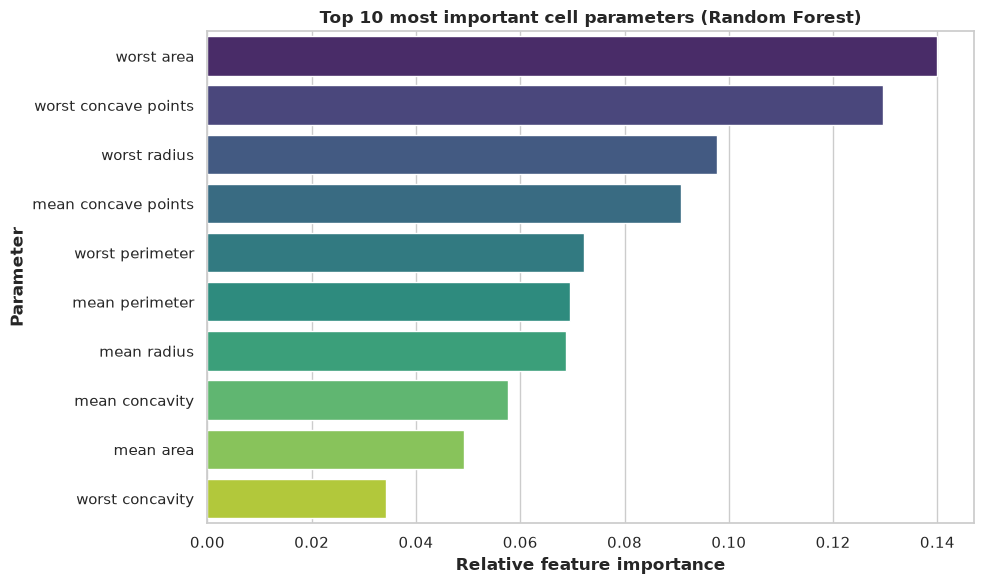

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Extract feature importances and map them to the column names from our original X dataset
feature_importances = pd.DataFrame({
    'Feature': X.columns, 
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Plot the top 10 most important features
plt.figure(figsize=(10, 6))
sns.barplot(
    x='Importance', 
    y='Feature', 
    data=feature_importances.head(10), 
    hue='Feature', 
    palette='viridis', 
    legend=False
)
plt.title('Top 10 most important cell parameters (Random Forest)', fontweight='bold')
plt.xlabel('Relative feature importance', fontweight='bold')
plt.ylabel('Parameter', fontweight='bold')
plt.tight_layout()
plt.show()